# Hometask


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.preprocessing  import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from sklearn.datasets import fetch_openml

## Classification:

Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### Dataset

In [57]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df = data_class.frame
display(df.head())
df.isnull().sum()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

### Preprocessing

In [58]:
df['workclass'] = df['workclass'].astype(object).fillna('Null')
df['occupation'] = df['occupation'].astype(object).fillna('Null')
df['native-country'] = df['native-country'].astype(object).fillna('Null')
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64

### Data encoding

In [59]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

le = LabelEncoder()
column_names = list(X.columns)
for i, col_name in enumerate(column_names):
    if X[col_name].dtype == 'object' or X[col_name].dtype.name == 'category':
        X_train_cat[col_name] = le.fit_transform(X_train[col_name].astype(str))
        X_test_cat[col_name] = le.transform(X_test[col_name].astype(str))
    else:
        X_train_cat[col_name] = X_train[col_name]
        X_test_cat[col_name] = X_test[col_name]
    
y_train_cat = le.fit_transform(y_train)
y_test_cat = le.transform(y_test)

le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
print ('X_test_cat.shape= ',X_test_cat.shape)
print ('y_test_cat.shape= ',y_test_cat.shape)


y:  {'<=50K': np.int64(0), '>50K': np.int64(1)}
X_train_cat.shape=  (36631, 14)
y_train_cat.shape=  (36631,)
X_test_cat.shape=  (12211, 14)
y_test_cat.shape=  (12211,)


### Classification

In [60]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

clf = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_grid = GridSearchCV(
    estimator=clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='accuracy', 
    n_jobs=-1,
    refit=True
)

clf_grid.fit(X_train_cat, y_train_cat)

y_pred_train = clf_grid.predict(X_train_cat)
y_pred_test = clf_grid.predict(X_test_cat)

metrics_data = [
    {"Data Set": "Train", 
     "Accuracy": accuracy_score(y_train_cat, y_pred_train), 
     "Precision": precision_score(y_train_cat, y_pred_train),
     "Recall": recall_score(y_train_cat, y_pred_train), 
     "F1-Score": f1_score(y_train_cat, y_pred_train)},

    {"Data Set": "Test", 
     "Accuracy": accuracy_score(y_test_cat, y_pred_test),
     "Precision": precision_score(y_test_cat, y_pred_test),
     "Recall": recall_score(y_test_cat, y_pred_test), 
     "F1-Score": f1_score(y_test_cat, y_pred_test)}
]

df_metrics = pd.DataFrame(metrics_data).round(3)
display(df_metrics)



c:\Users\poyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:19:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Data Set,Accuracy,Precision,Recall,F1-Score
0,Train,0.886,0.816,0.678,0.741
1,Test,0.881,0.787,0.674,0.726


### Feature importance

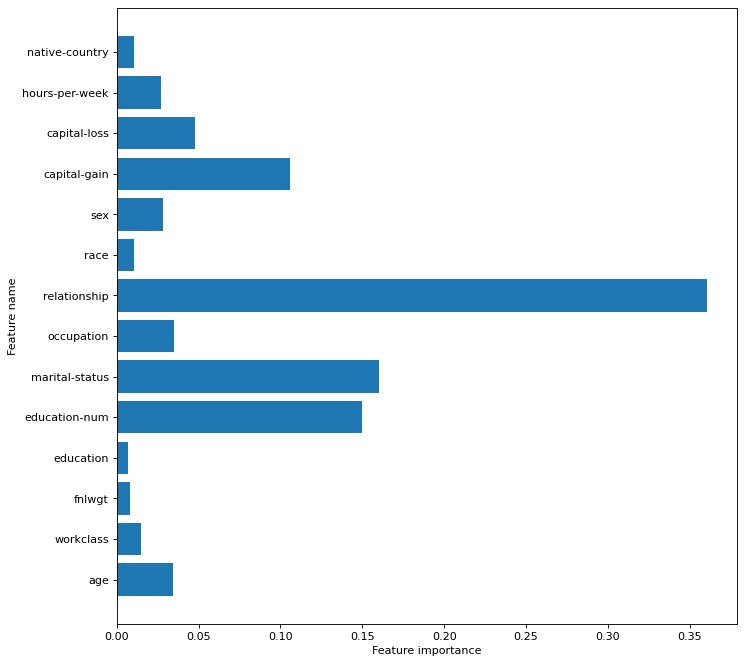

In [65]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(10, 10), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

plot_feature_importances(clf_grid.best_estimator_, X_train_cat.columns)

## Regression:

Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

### Dataset

In [28]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
display(df_house.head())
display(df_house.isnull().sum().sort_values(ascending=False).head(20))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageFinish      81
GarageQual        81
GarageYrBlt       81
GarageType        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
Condition2         0
dtype: int64

### Preprocessing

In [25]:
cat_cols = df_house.select_dtypes(include=['object', 'category']).columns
num_cols = df_house.select_dtypes(exclude=['object', 'category']).columns
df_house[cat_cols] = df_house[cat_cols].astype(object).fillna('None')
df_house[num_cols] = df_house[num_cols].fillna(df_house[num_cols].median())
df_final = pd.get_dummies(df_house)
display(df_house.isnull().sum().sort_values(ascending=False).head(20))

Id              0
MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
Alley           0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
dtype: int64

### Data encoding

In [ ]:
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print('X_train.shape= ',X_train.shape)
print('y_train.shape= ',y_train.shape)
print('X_test.shape= ',X_test.shape)
print('y_test.shape= ',y_test.shape)


X_train.shape=  (1095, 304)
y_train.shape=  (1095,)
X_test.shape=  (365, 304)
y_test.shape=  (365,)


### Regression

In [36]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

reg = XGBRegressor(
    random_state=42,
    use_label_encoder=False,
    eval_metric='rmse'
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

reg_grid = GridSearchCV(
    estimator=reg, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='r2', 
    n_jobs=-1,
    refit=True
)

reg_grid.fit(X_train, y_train)

y_pred_train = reg_grid.predict(X_train)
y_pred_test = reg_grid.predict(X_test)

metrics_data = [
    {"Data Set": "Train", 
     "R2 Score": r2_score(y_train, y_pred_train), 
     "MAE": mean_absolute_error(y_train, y_pred_train),
     "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train))},

    {"Data Set": "Test", 
     "R2 Score": r2_score(y_test, y_pred_test),
     "MAE": mean_absolute_error(y_test, y_pred_test),
     "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test))}
]

df_metrics = pd.DataFrame(metrics_data).round(3)
display(df_metrics)



c:\Users\poyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:06:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Data Set,R2 Score,MAE,RMSE
0,Train,0.991,5436.318,7399.573
1,Test,0.911,16234.414,25032.453


### Feature importance

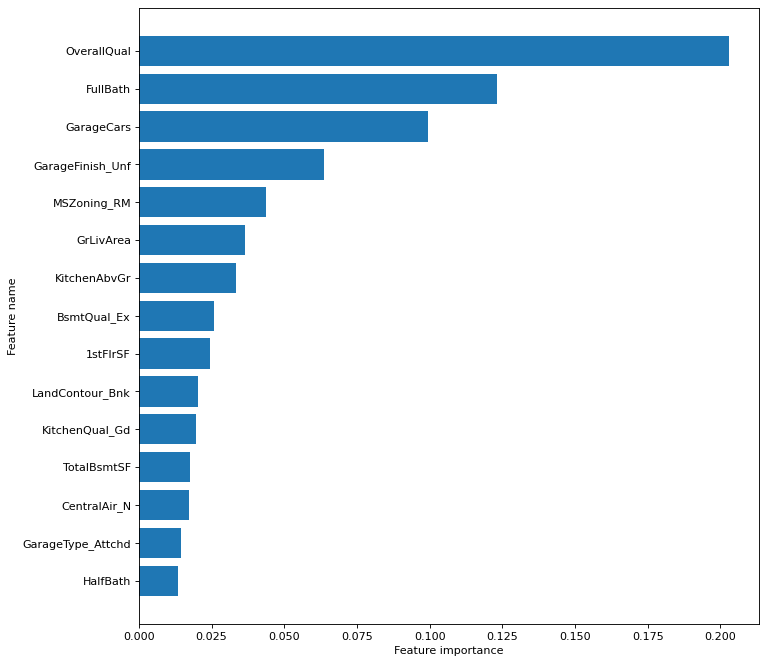

In [53]:
def plot_feature_importances(reg, features):
    # 1. Створюємо Series для зручного сортування та маніпуляцій
    importances = pd.Series(reg.feature_importances_, index=features)
    importances = importances.sort_values(ascending=False).head(15)
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(10, 10), dpi=80)
    c_features = len(importances)
    plt.barh(range(c_features), importances.values)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), importances.index)
    
plot_feature_importances(reg_grid.best_estimator_, X_train.columns)